<a href="https://colab.research.google.com/github/DarkDreamz-38/AI-Lab/blob/main/BFS%20and%20DFS%20Traversal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter number of nodes: 6
Enter node 1: A
Enter node 2: B
Enter node 3: C
Enter node 4: D
Enter node 5: E
Enter node 6: F
Enter number of edges: 5
Enter edge 1: A B
Enter edge 2: A C
Enter edge 3: B D
Enter edge 4: B E
Enter edge 5: C F
Enter starting node: A

BFS Traversal:
A -> B -> C -> D -> E -> F

DFS Traversal:
A -> B -> D -> E -> C -> F


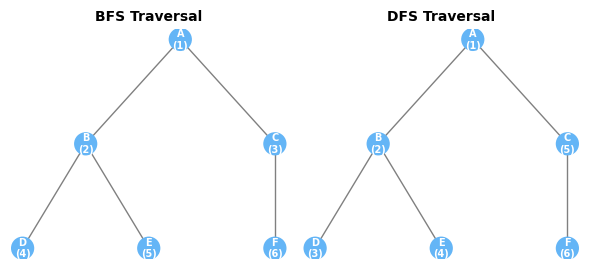

In [8]:
from collections import deque
import matplotlib.pyplot as plt

n = int(input("Enter number of nodes: "))

nodes = []

for i in range(n):
    node = input(f"Enter node {i + 1}: ")
    nodes.append(node)

graph = {}

for node in nodes:
    graph[node] = []

e = int(input("Enter number of edges: "))

for i in range(e):
    u, v = input(f"Enter edge {i + 1}: ").split()

    graph[u].append(v)
    graph[v].append(u)

start = input("Enter starting node: ")



def bfs(graph, start):
    visited = set()
    queue = deque()

    order = []
    parent = {}

    queue.append(start)
    visited.add(start)
    parent[start] = None

    while queue:
        current = queue.popleft()
        order.append(current)

        for neighbour in graph[current]:
            if neighbour not in visited:
                visited.add(neighbour)
                parent[neighbour] = current
                queue.append(neighbour)

    return order, parent



def dfs(graph, start):
    visited = set()

    order = []
    parent = {}

    parent[start] = None

    def visit(current):
        visited.add(current)
        order.append(current)

        for neighbour in graph[current]:
            if neighbour not in visited:
                parent[neighbour] = current
                visit(neighbour)

    visit(start)

    return order, parent



def get_positions(parent, root):

    children = {}

    for node in parent:
        children[node] = []

    for node in parent:
        if parent[node] is not None:
            children[parent[node]].append(node)

    positions = {}
    x_position = [0]

    def place(node, depth):

        if len(children[node]) == 0:

            positions[node] = (
                x_position[0] * 0.6,
                -depth * 0.6
            )

            x_position[0] += 1

        else:

            for child in children[node]:
                place(child, depth + 1)

            first_child = children[node][0]
            last_child = children[node][-1]

            first_x = positions[first_child][0]
            last_x = positions[last_child][0]

            positions[node] = (
                (first_x + last_x) / 2,
                -depth * 0.6
            )

    place(root, 0)

    return positions



def draw_tree(ax, order, parent, title):

    positions = get_positions(parent, start)

    traversal_number = {}

    for i, node in enumerate(order, 1):
        traversal_number[node] = i


    for node in parent:

        if parent[node] is not None:

            parent_x, parent_y = positions[parent[node]]
            node_x, node_y = positions[node]

            ax.plot(
                [parent_x, node_x],
                [parent_y, node_y],
                color="gray",
                linewidth=1,
                zorder=1
            )


    for node in order:

        x, y = positions[node]

        ax.scatter(
            x,
            y,
            s=280,
            color="#64B5F6",
            edgecolors="none",
            zorder=2
        )

        # Node name + traversal order
        label = node + "\n(" + str(traversal_number[node]) + ")"

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=7,
            color="white",
            fontweight="bold",
            zorder=3
        )

    ax.set_title(
        title,
        fontsize=10,
        fontweight="bold"
    )

    ax.axis("off")



bfs_order, bfs_parent = bfs(graph, start)

dfs_order, dfs_parent = dfs(graph, start)



print("\nBFS Traversal:")
print(" -> ".join(bfs_order))

print("\nDFS Traversal:")
print(" -> ".join(dfs_order))



fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(6, 2.8)
)

draw_tree(
    ax1,
    bfs_order,
    bfs_parent,
    "BFS Traversal"
)

draw_tree(
    ax2,
    dfs_order,
    dfs_parent,
    "DFS Traversal"
)

plt.tight_layout()
plt.show()